# 004 — FD Characterization: AFTER signatures by driver type

**Scientific question:** Does the temporal complexity signature in the neutron monitor network encode information about the type and intensity of the interplanetary driver, beyond what amplitude alone captures?

**Strategy:** Match AFTER events to FEID at ±36h, assign driver type (SSC/SI/NaN→CIR-like), then characterize the AFTER network signature by driver type across the solar cycle.

## 0. Imports & paths

In [1]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from IPython.display import display

BASE       = Path("Results_v2_4")
OUT        = BASE / "Characterization"
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.labelsize":   12,
    "axes.titlesize":   12,
    "legend.fontsize":  9,
    "figure.dpi":       150,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})

# Color scheme by driver type
DRIVER_COLORS = {
    "SSC":          "#d73027",
    "SI":           "#fc8d59",
    "unclassified": "#4575b4",   # antes "CIR"
    "unmatched":    "#bdbdbd",
}
DRIVER_LABELS = {
    "SSC":          "ICME-shock (SSC)",
    "SI":           "Weak impulse (SI)",
    "unclassified": "Unclassified onset (NaN)",   # antes "CIR/diffuse"
    "unmatched":    "AFTER-only",
}

MATCH_TOL_H = 36.0   # physical tolerance — see diagnosis

def savefig(name):
    plt.savefig(OUT / name, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


## 1. Load data

In [2]:
# AFTER catalogue
cat = pd.read_csv(BASE / "AFTER_catalog_detector.csv")
cat["repr_time"] = pd.to_datetime(cat["repr_time"])
if cat["repr_time"].dt.tz is not None:
    cat["repr_time"] = cat["repr_time"].dt.tz_convert(None)

# Use anchor_onset_time if available (closer to FEID time)
if "anchor_onset_time" in cat.columns:
    cat["match_time"] = pd.to_datetime(cat["anchor_onset_time"])
    if cat["match_time"].dt.tz is not None:
        cat["match_time"] = cat["match_time"].dt.tz_convert(None)
else:
    cat["match_time"] = cat["repr_time"]

cat["year"] = cat["repr_time"].dt.year
cat["month"] = cat["repr_time"].dt.month

# FEID
feid = pd.read_parquet("feid_clean.parquet")
feid.index = pd.to_datetime(feid.index)
feid["t_izmiran"] = feid.index
if feid["t_izmiran"].dt.tz is not None:
    feid["t_izmiran"] = feid["t_izmiran"].dt.tz_convert(None)
feid["year"] = feid["t_izmiran"].dt.year
ons_col = "ons type" if "ons type" in feid.columns else "ons"

# Station panels (for episode duration from trigger catalog)
tc = pd.read_csv(BASE / "trigger_catalog_detector.csv")
tc["repr_time"] = pd.to_datetime(tc["repr_time"])
if tc["repr_time"].dt.tz is not None:
    tc["repr_time"] = tc["repr_time"].dt.tz_convert(None)

print(f"AFTER catalogue: {len(cat):,} events")
print(f"FEID total:      {len(feid):,} events")
print(f"Trigger catalog: {len(tc):,} groups")
print(f"\nFEID onset distribution:")
print(feid[ons_col].value_counts(dropna=False).to_string())


AFTER catalogue: 908 events
FEID total:      1,475 events
Trigger catalog: 908 groups

FEID onset distribution:
ons type
None    1342
SSC      112
SI        21


Amplitude comparison data:
      driver  N_feid  N_after  N_amp  pct_after  pct_amp
         SSC     112       75     42      66.96    37.50
          SI      21       13      8      61.90    38.10
unclassified    1342      534    160      39.79    11.92


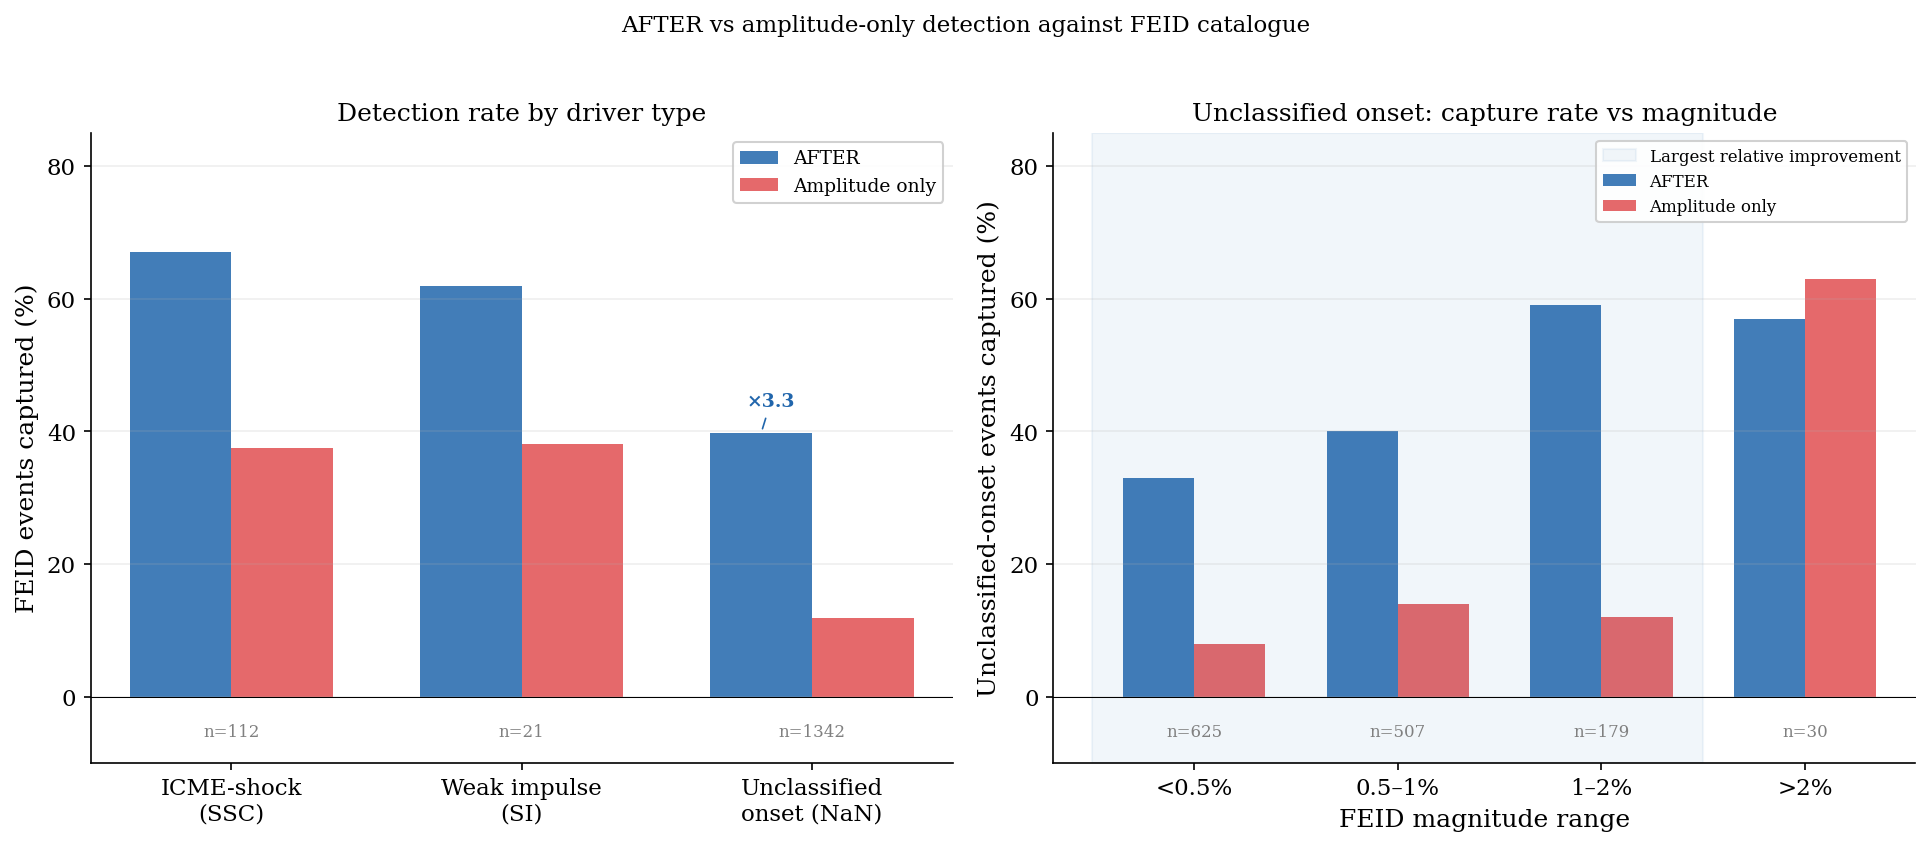

✓ fig1_amplitude_comparison.pdf


In [3]:
# ── Fig: AFTER vs amplitude-only comparison ───────────────────────────────────
# Requires: Results_v2_4/amplitude_vs_after_comparison.csv
# Output:   Results_v2_4/Characterization/fig1_amplitude_comparison.pdf

amp_df = pd.read_csv("Results_v2_4/amplitude_vs_after_comparison.csv")
# Normalizar nomenclatura del CSV (generado antes del cambio CIR→unclassified)
amp_df["driver"] = amp_df["driver"].replace("CIR", "unclassified")
print("Amplitude comparison data:")
print(amp_df[["driver","N_feid","N_after","N_amp","pct_after","pct_amp"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Left panel: capture fraction by driver type ───────────────────────────────
driver_order  = ["SSC", "SI", "unclassified"]
driver_labels = {
    "SSC":          "ICME-shock\n(SSC)",
    "SI":           "Weak impulse\n(SI)",
    "unclassified": "Unclassified\nonset (NaN)",
}

x      = np.arange(len(driver_order))
width  = 0.35
ax     = axes[0]

pct_after = [amp_df.loc[amp_df["driver"]==d, "pct_after"].values[0]
             for d in driver_order]
pct_amp   = [amp_df.loc[amp_df["driver"]==d, "pct_amp"].values[0]
             for d in driver_order]
n_feid    = [int(amp_df.loc[amp_df["driver"]==d, "N_feid"].values[0])
             for d in driver_order]

bars_after = ax.bar(x - width/2, pct_after, width,
                     color="#2166ac", alpha=0.85, label="AFTER")
bars_amp   = ax.bar(x + width/2, pct_amp,   width,
                     color="#d7191c", alpha=0.65, label="Amplitude only")

# Annotate with N_feid
for i, (xa, n) in enumerate(zip(x, n_feid)):
    ax.text(xa, -6, f"n={n}", ha="center", fontsize=8, color="gray")

# Factor improvement annotation for unclassified
factor = pct_after[2] / pct_amp[2]
ax.annotate(f"×{factor:.1f}",
            xy=(x[2] - width/2, pct_after[2]),
            xytext=(x[2] - width/2 - 0.05, pct_after[2] + 4),
            fontsize=9, color="#2166ac", fontweight="bold",
            arrowprops=dict(arrowstyle="-", color="#2166ac", lw=0.8))

ax.set_xticks(x)
ax.set_xticklabels([driver_labels[d] for d in driver_order])
ax.set_ylabel("FEID events captured (%)")
ax.set_title("Detection rate by driver type")
ax.set_ylim(-10, 85)
ax.axhline(0, color="black", lw=0.5)
ax.legend(framealpha=0.9)
ax.grid(True, axis="y", alpha=0.2)

# ── Right panel: capture fraction by magnitude (unclassified only) ───────────
ax2 = axes[1]

# Data from test_amplitude_only.py output
mag_labels = ["<0.5%", "0.5–1%", "1–2%", ">2%"]
pct_after_mag = [33, 40, 59, 57]   # from test_amplitude_only output
pct_amp_mag   = [ 8, 14, 12, 63]   # from test_amplitude_only output
n_mag         = [625, 507, 179, 30] # N per bin

x2    = np.arange(len(mag_labels))
width2 = 0.35

ax2.bar(x2 - width2/2, pct_after_mag, width2,
         color="#2166ac", alpha=0.85, label="AFTER")
ax2.bar(x2 + width2/2, pct_amp_mag,   width2,
         color="#d7191c", alpha=0.65, label="Amplitude only")

# Shade region of largest relative improvement (first three bins)
ax2.axvspan(-0.5, 2.5, alpha=0.06, color="#2166ac",
             label="Largest relative improvement")

# Annotate N per bin
for i, (xa, n) in enumerate(zip(x2, n_mag)):
    ax2.text(xa, -6, f"n={n}", ha="center", fontsize=8, color="gray")

ax2.set_xticks(x2)
ax2.set_xticklabels(mag_labels)
ax2.set_xlabel("FEID magnitude range")
ax2.set_ylabel("Unclassified-onset events captured (%)")
ax2.set_title("Unclassified onset: capture rate vs magnitude")
ax2.set_ylim(-10, 85)
ax2.axhline(0, color="black", lw=0.5)
ax2.legend(framealpha=0.9, fontsize=8)
ax2.grid(True, axis="y", alpha=0.2)

plt.suptitle("AFTER vs amplitude-only detection against FEID catalogue",
             y=1.02, fontsize=11)
plt.tight_layout()
savefig("fig1_amplitude_comparison.pdf")
print("✓ fig1_amplitude_comparison.pdf")

## 2. AFTER ↔ FEID matching at ±36h

We use ±36h because the AFTER repr_time (deepest station minimum) systematically lags the FEID time (global minimum) by 20–48h for large, multi-phase events. This tolerance reflects the physical difference in event time definition between the two frameworks.

In [4]:
TOL = pd.Timedelta(hours=MATCH_TOL_H)

# One-to-one matching: for each AFTER event find closest FEID
# Use match_time (anchor_onset_time preferred)
after_times = list(cat["match_time"])
feid_times  = list(feid["t_izmiran"])

# Build distance matrix efficiently
print("Building matches...", flush=True)

# For each AFTER event: find closest FEID within tolerance
after_feid_dt   = []
after_feid_idx  = []
after_feid_ons  = []
after_feid_mag  = []
after_feid_vmax = []
after_feid_bmax = []

for i, ta in enumerate(after_times):
    dts = [(abs(tf - ta), j) for j, tf in enumerate(feid_times)
           if abs(tf - ta) <= TOL]
    if dts:
        dt_min, j_best = min(dts, key=lambda x: x[0])
        after_feid_dt.append(dt_min.total_seconds()/3600)
        after_feid_idx.append(j_best)
        after_feid_ons.append(feid.iloc[j_best][ons_col])
        after_feid_mag.append(feid.iloc[j_best]["magnitude"])
        after_feid_vmax.append(feid.iloc[j_best].get("V max", np.nan))
        after_feid_bmax.append(feid.iloc[j_best].get("B max", np.nan))
    else:
        after_feid_dt.append(np.nan)
        after_feid_idx.append(-1)
        after_feid_ons.append(np.nan)
        after_feid_mag.append(np.nan)
        after_feid_vmax.append(np.nan)
        after_feid_bmax.append(np.nan)

cat["feid_dt_h"]    = after_feid_dt
cat["feid_idx"]     = after_feid_idx
cat["feid_ons"]     = after_feid_ons
cat["feid_mag_36h"] = after_feid_mag
cat["feid_vmax_36h"]= after_feid_vmax
cat["feid_bmax_36h"]= after_feid_bmax
cat["feid_matched_36h"] = cat["feid_idx"] >= 0

# Assign driver type
def assign_driver(ons):
    if pd.isna(ons):
        return "unclassified"
    if ons == "SSC":
        return "SSC"
    if ons == "SI":
        return "SI"
    return "unclassified"   # iSW también cae aquí si aparece

cat["driver"] = cat["feid_ons"].apply(assign_driver)
cat.loc[~cat["feid_matched_36h"], "driver"] = "unmatched"

# Summary
n_matched = cat["feid_matched_36h"].sum()
print(f"\nMatching results at ±{MATCH_TOL_H:.0f}h:")
print(f"  Matched:   {n_matched:>5} ({n_matched/len(cat)*100:.1f}%)")
print(f"  Unmatched: {len(cat)-n_matched:>5} ({(1-n_matched/len(cat))*100:.1f}%)")
print(f"\nDriver distribution:")
print(cat["driver"].value_counts().to_string())
print(f"\nMatched events by driver:")
matched = cat[cat["feid_matched_36h"]].copy()
print(matched["driver"].value_counts().to_string())

cat.to_csv(OUT / "AFTER_catalog_characterization.csv", index=False)
print(f"\n✓ Saved: AFTER_catalog_characterization.csv")


Building matches...

Matching results at ±36h:
  Matched:     729 (80.3%)
  Unmatched:   179 (19.7%)

Driver distribution:
driver
unclassified    641
unmatched       179
SSC              75
SI               13

Matched events by driver:
driver
unclassified    641
SSC              75
SI               13

✓ Saved: AFTER_catalog_characterization.csv


## 3. Compute episode properties for characterization

In [5]:
# Merge trigger catalog properties into cat
tc_props = tc[["repr_time","group_span_h","n_trigger_stations",
               "trigger_A_complex_mean","trigger_drop_max",
               "trigger_drop_mean"]].copy()
tc_props["repr_time"] = pd.to_datetime(tc_props["repr_time"])
if tc_props["repr_time"].dt.tz is not None:
    tc_props["repr_time"] = tc_props["repr_time"].dt.tz_convert(None)

# Match by repr_time (should be exact)
cat_merged = cat.merge(tc_props, on="repr_time", how="left",
                        suffixes=("","_tc"))

# Key characterization variables
char_vars = {
    "duration_h":       "group_span_h",          # episode duration
    "A_complex_mean":   "trigger_A_complex_mean", # mean complexity
    "drop_max":         "trigger_drop_max",        # max amplitude drop
    "n_trig_stations":  "n_trigger_stations",      # triggering stations
    "n_sup_stations":   "n_supported_stations",    # supporting stations
}

for new_col, src_col in char_vars.items():
    if src_col in cat_merged.columns:
        cat_merged[new_col] = cat_merged[src_col]

# δt: time from AFTER match_time to FEID time (signed)
# Positive = AFTER lags FEID (AFTER sees the event later)
# Negative = AFTER leads FEID (AFTER sees it earlier)
cat_merged["delta_t_h"] = cat_merged["feid_dt_h"]  # absolute for now

print("Episode properties added:")
for v in char_vars:
    if v in cat_merged.columns:
        print(f"  {v}: mean={cat_merged[v].mean():.2f}  "
              f"median={cat_merged[v].median():.2f}")

cat_merged.to_csv(OUT / "AFTER_catalog_characterization.csv", index=False)
cat_char = cat_merged.copy()
matched_char = cat_char[cat_char["feid_matched_36h"]].copy()
print(f"\nFinal characterization dataset: {len(cat_char):,} events")
print(f"Matched subset:                  {len(matched_char):,} events")


Episode properties added:
  duration_h: mean=45.45  median=37.53
  A_complex_mean: mean=6.79  median=6.40
  drop_max: mean=5.76  median=5.03
  n_trig_stations: mean=3.61  median=3.00
  n_sup_stations: mean=6.57  median=6.00

Final characterization dataset: 908 events
Matched subset:                  729 events


## 4. Statistical characterization by driver type

For each driver type (SSC, SI, CIR/diffuse, unmatched): distributions of key network signature variables.

In [6]:
drivers = ["SSC","SI","CIR","unmatched"]

char_cols = ["n_sup_stations","duration_h","A_complex_mean",
             "drop_max","feid_mag_36h","feid_vmax_36h"]

print("=== Statistical characterization by driver type ===\n")
summary_rows = []
for col in char_cols:
    if col not in cat_char.columns:
        continue
    print(f"--- {col} ---")
    for drv in drivers:
        sub = cat_char[cat_char["driver"]==drv][col].dropna()
        if len(sub) == 0:
            continue
        summary_rows.append({
            "variable": col,
            "driver":   drv,
            "N":        len(sub),
            "mean":     sub.mean(),
            "median":   sub.median(),
            "std":      sub.std(),
            "q25":      sub.quantile(0.25),
            "q75":      sub.quantile(0.75),
        })
        print(f"  {drv:12s} n={len(sub):>4}  "
              f"mean={sub.mean():.2f}  median={sub.median():.2f}  "
              f"std={sub.std():.2f}")
    print()

summary = pd.DataFrame(summary_rows).round(3)
summary.to_csv(OUT / "table_characterization_by_driver.csv", index=False)
print("✓ Saved: table_characterization_by_driver.csv")

# KS tests: SSC vs CIR for key variables
print("\n=== Kolmogorov-Smirnov tests: SSC vs CIR ===")
ssc = cat_char[cat_char["driver"]=="SSC"]
cir = cat_char[cat_char["driver"]=="unclassified"]
for col in ["n_sup_stations","A_complex_mean","drop_max","duration_h"]:
    if col not in cat_char.columns:
        continue
    x = ssc[col].dropna()
    y = cir[col].dropna()
    if len(x)>5 and len(y)>5:
        ks, pval = stats.ks_2samp(x, y)
        print(f"  {col:25s}: KS={ks:.3f}  p={pval:.4f}  "
              f"{'***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else 'ns'}")


=== Statistical characterization by driver type ===

--- n_sup_stations ---
  SSC          n=  75  mean=11.08  median=12.00  std=3.78
  SI           n=  13  mean=12.46  median=13.00  std=2.93
  unmatched    n= 179  mean=5.72  median=5.00  std=4.07

--- duration_h ---
  SSC          n=  75  mean=55.33  median=49.13  std=29.12
  SI           n=  13  mean=69.06  median=65.60  std=27.94
  unmatched    n= 179  mean=41.51  median=34.60  std=31.21

--- A_complex_mean ---
  SSC          n=  75  mean=6.66  median=6.33  std=1.71
  SI           n=  13  mean=6.47  median=6.26  std=0.84
  unmatched    n= 179  mean=7.09  median=6.54  std=3.24

--- drop_max ---
  SSC          n=  75  mean=7.28  median=6.54  std=3.18
  SI           n=  13  mean=8.16  median=7.06  std=3.22
  unmatched    n= 179  mean=5.58  median=4.80  std=2.90

--- feid_mag_36h ---
  SSC          n=  75  mean=2.48  median=1.60  std=2.61
  SI           n=  13  mean=1.98  median=0.96  std=2.92

--- feid_vmax_36h ---
  SSC          n=  7

### Figure 1 — Network signature distributions by driver type

Key result figure: shows whether complexity/coherence discriminates drivers.

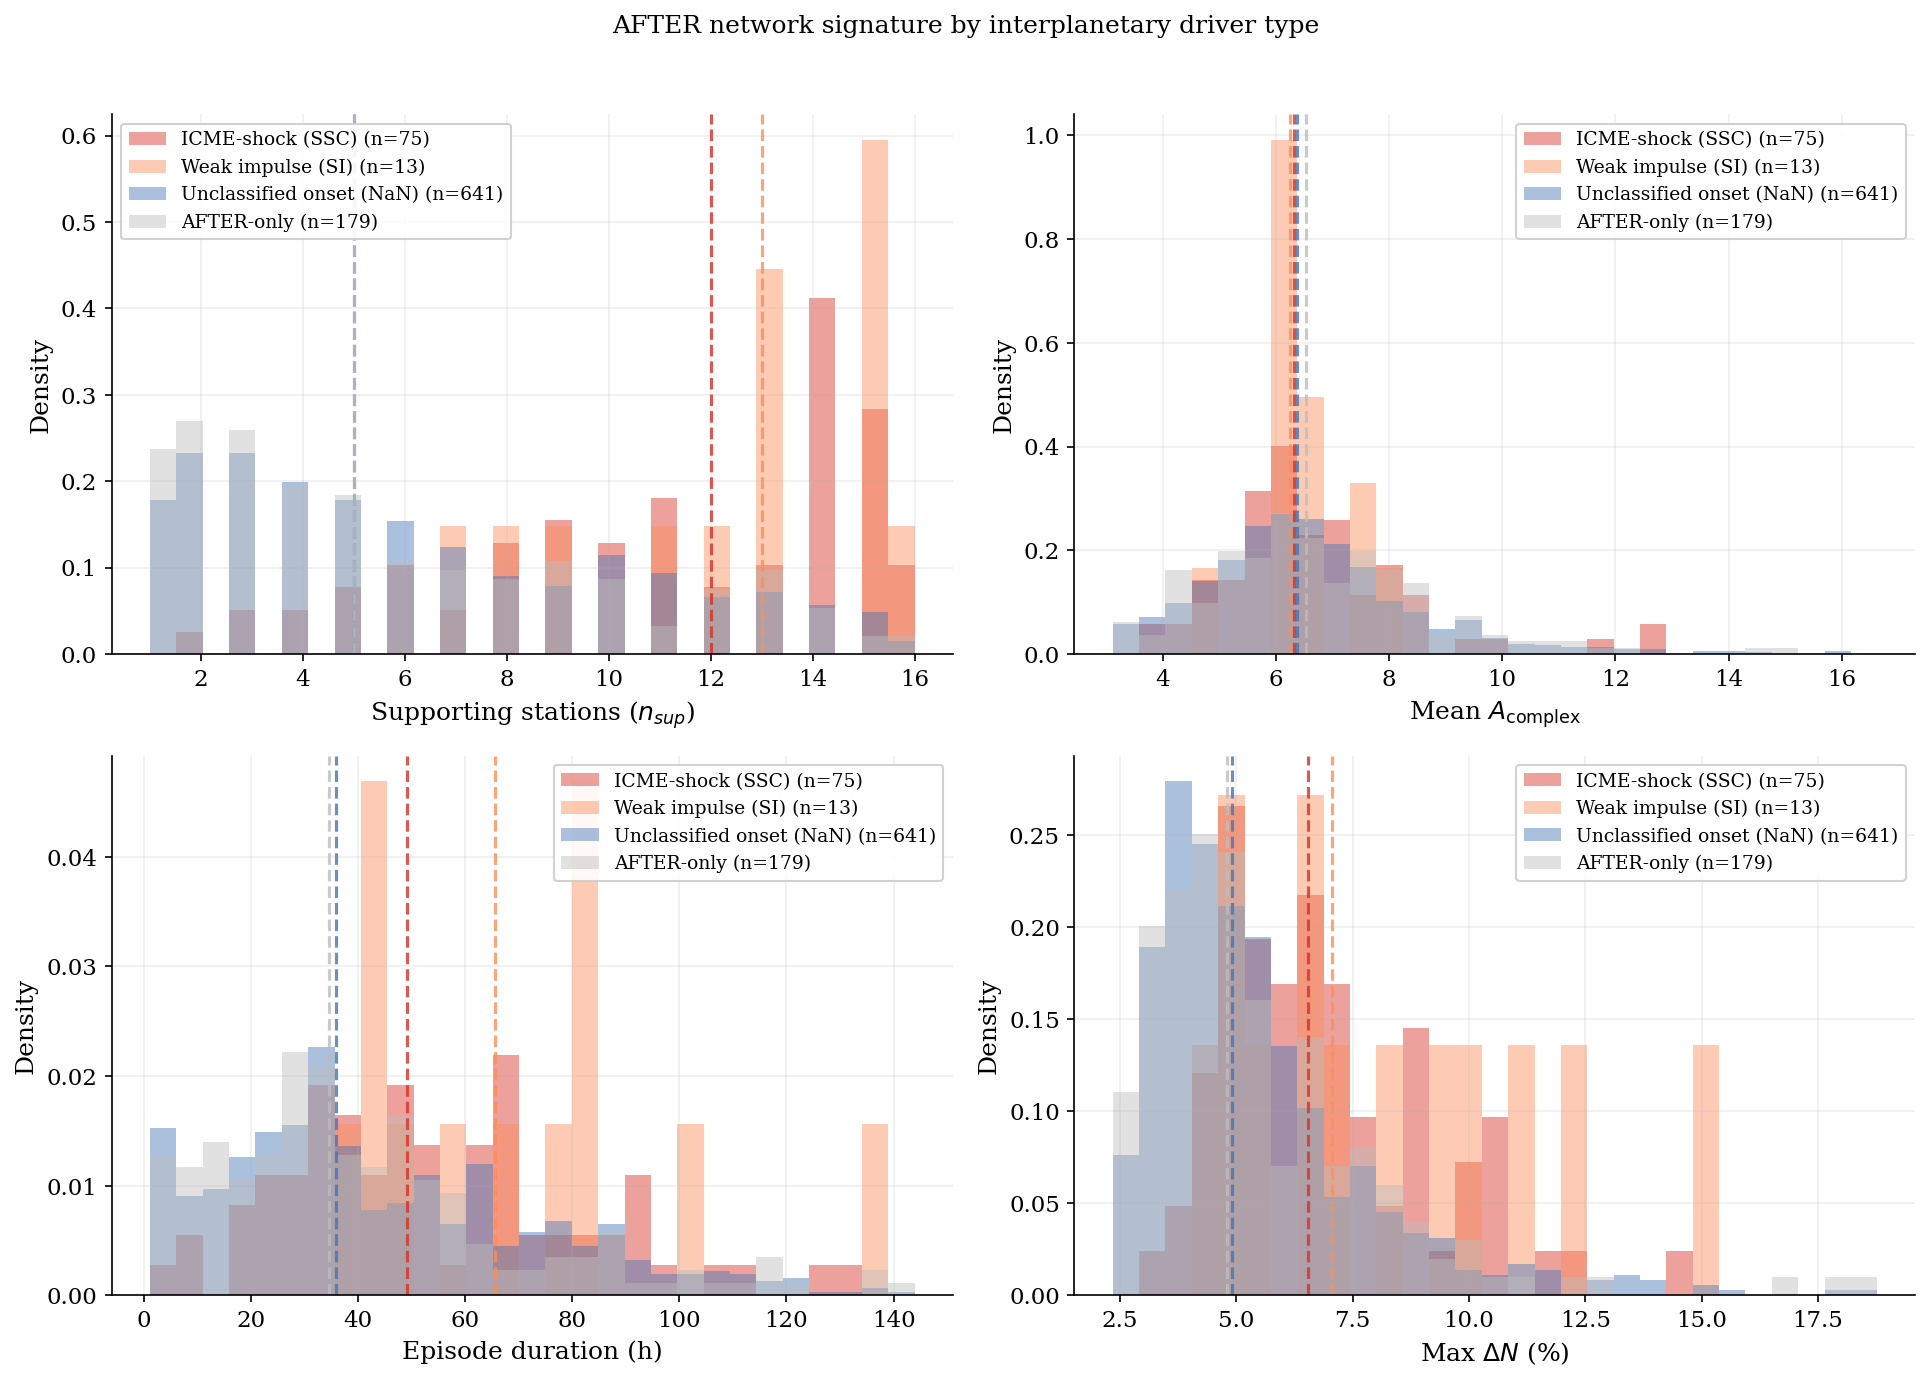

In [7]:
plot_vars = [
    ("n_sup_stations",  "Supporting stations ($n_{sup}$)"),
    ("A_complex_mean",  r"Mean $A_{\mathrm{complex}}$"),
    ("duration_h",      "Episode duration (h)"),
    ("drop_max",        r"Max $\Delta N$ (%)"),
]

plot_drivers = ["SSC","SI","unclassified","unmatched"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (col, xlabel) in zip(axes, plot_vars):
    if col not in cat_char.columns:
        continue

    all_vals = cat_char[col].dropna()
    bins = np.linspace(all_vals.quantile(0.01),
                        all_vals.quantile(0.99), 30)

    for drv in plot_drivers:
        sub = cat_char[cat_char["driver"]==drv][col].dropna()
        if len(sub) < 3:
            continue
        ax.hist(sub, bins=bins, density=True,
                color=DRIVER_COLORS[drv], alpha=0.45,
                label=f"{DRIVER_LABELS[drv]} (n={len(sub)})")
        ax.axvline(sub.median(), color=DRIVER_COLORS[drv],
                   ls="--", lw=1.5, alpha=0.8)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.2)

plt.suptitle(
    "AFTER network signature by interplanetary driver type",
    y=1.02, fontsize=12)
plt.tight_layout()
savefig("fig1_driver_distributions.pdf")


### Figure 2 — Feature space: network coherence vs complexity

Do SSC/SI/CIR separate in the (nsup, A_complex) plane?

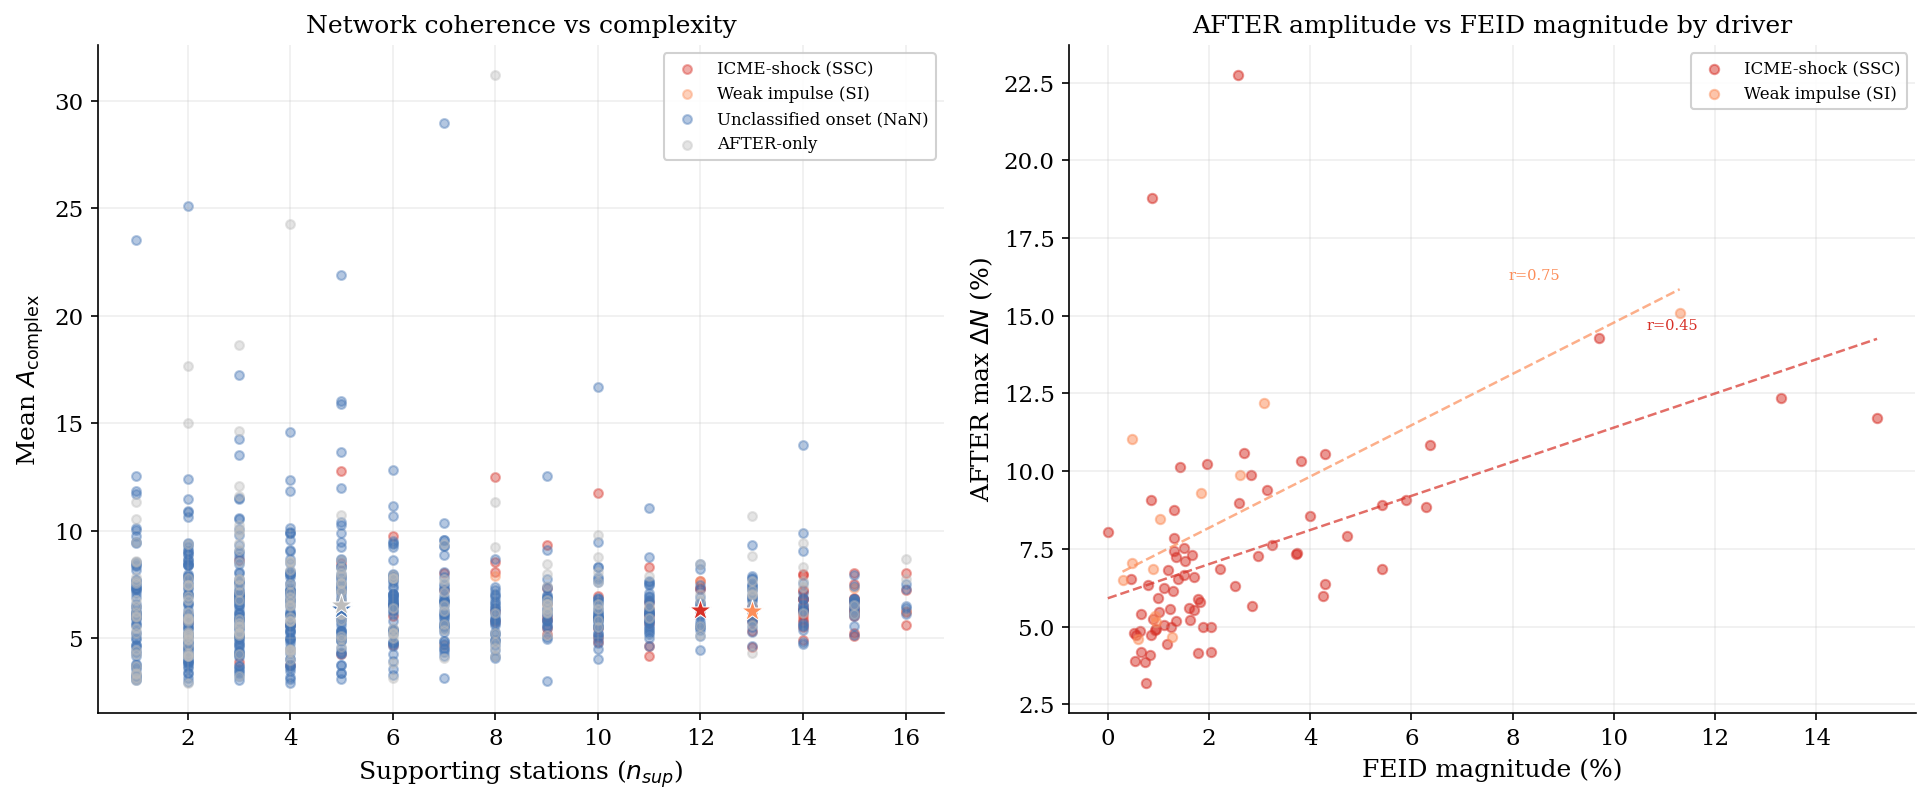

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: nsup vs A_complex_mean
ax = axes[0]
for drv in plot_drivers:
    sub = cat_char[cat_char["driver"]==drv]
    if len(sub) < 3:
        continue
    ax.scatter(sub["n_sup_stations"], sub["A_complex_mean"],
               color=DRIVER_COLORS[drv], alpha=0.4, s=18,
               label=DRIVER_LABELS[drv])
    # Centroid
    ax.scatter(sub["n_sup_stations"].median(),
               sub["A_complex_mean"].median(),
               color=DRIVER_COLORS[drv], s=120, marker="*",
               edgecolors="white", linewidths=0.5, zorder=5)

ax.set_xlabel("Supporting stations ($n_{sup}$)")
ax.set_ylabel(r"Mean $A_{\mathrm{complex}}$")
ax.set_title("Network coherence vs complexity")
ax.legend(fontsize=8, framealpha=0.9)
ax.grid(True, alpha=0.2)

# Right: drop_max vs feid_magnitude (for matched events)
ax = axes[1]
for drv in ["SSC","SI","CIR"]:
    sub = matched_char[matched_char["driver"]==drv]
    if len(sub) < 3:
        continue
    ax.scatter(sub["feid_mag_36h"], sub["drop_max"],
               color=DRIVER_COLORS[drv], alpha=0.5, s=20,
               label=DRIVER_LABELS[drv])
    # Regression line
    x = sub["feid_mag_36h"].dropna()
    y = sub["drop_max"].dropna()
    common_idx = x.index.intersection(y.index)
    if len(common_idx) > 5:
        slope, intercept, r, p, _ = stats.linregress(
            x.loc[common_idx], y.loc[common_idx])
        xr = np.linspace(x.min(), x.max(), 50)
        ax.plot(xr, slope*xr+intercept,
                color=DRIVER_COLORS[drv], lw=1.2, ls="--", alpha=0.7)
        ax.text(x.max()*0.7, slope*x.max()+intercept+0.3,
                f"r={r:.2f}", color=DRIVER_COLORS[drv], fontsize=7)

ax.set_xlabel("FEID magnitude (%)")
ax.set_ylabel(r"AFTER max $\Delta N$ (%)")
ax.set_title("AFTER amplitude vs FEID magnitude by driver")
ax.legend(fontsize=8, framealpha=0.9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
savefig("fig2_feature_space.pdf")


### Figure 3 — Driver composition across the solar cycle

How does the AFTER driver mix change from solar minimum to maximum?

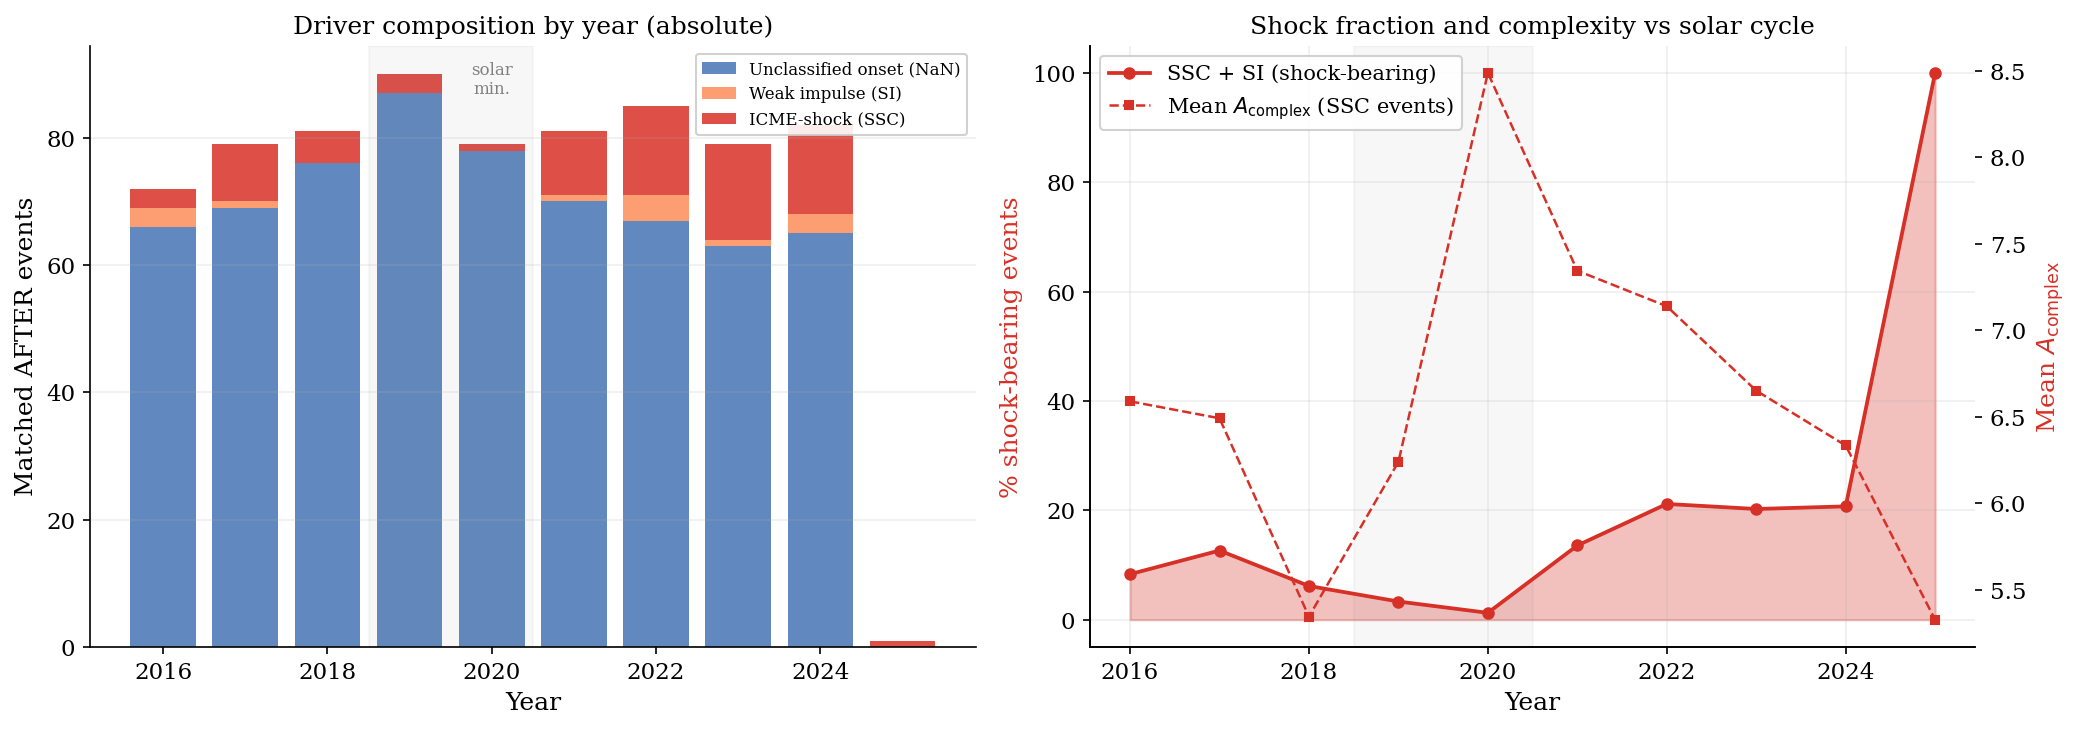

In [9]:
# Annual driver composition (matched events only)
yr_driver = (matched_char.groupby(["year","driver"])
             .size()
             .unstack(fill_value=0))

# Ensure all driver columns present
for drv in ["SSC","SI","CIR"]:
    if drv not in yr_driver.columns:
        yr_driver[drv] = 0

yr_total = matched_char.groupby("year").size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: stacked bar — absolute counts
x = yr_driver.index.astype(int)
bottom = np.zeros(len(x))
# Ensure all driver columns present
for drv in ["SSC", "SI", "unclassified"]:  # ← cambiar CIR
    if drv not in yr_driver.columns:
        yr_driver[drv] = 0

# Left: stacked bar
for drv in ["unclassified", "SI", "SSC"]:  # ← cambiar CIR
    if drv in yr_driver.columns:
        vals = yr_driver[drv].values
        axes[0].bar(x, vals, bottom=bottom,
                    color=DRIVER_COLORS[drv], alpha=0.85,
                    label=DRIVER_LABELS[drv])
        bottom += vals

axes[0].axvspan(2018.5, 2020.5, alpha=0.06, color="gray")
axes[0].text(2020, axes[0].get_ylim()[1]*0.92,
             "solar\nmin.", ha="center", fontsize=8, color="gray")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Matched AFTER events")
axes[0].set_title("Driver composition by year (absolute)")
axes[0].legend(fontsize=8, framealpha=0.9)
axes[0].grid(True, axis="y", alpha=0.2)

# Right: fraction SSC+SI (shock-bearing) by year
pct_shock = ((yr_driver.get("SSC",0) + yr_driver.get("SI",0)) /
              yr_total * 100).fillna(0)

axes[1].fill_between(x, pct_shock.values, alpha=0.3,
                      color=DRIVER_COLORS["SSC"])
axes[1].plot(x, pct_shock.values, marker="o",
             color=DRIVER_COLORS["SSC"], lw=1.8, ms=5,
             label="SSC + SI (shock-bearing)")

# Mean A_complex of SSC events by year
ac_ssc_yr = (matched_char[matched_char["driver"]=="SSC"]
             .groupby("year")["A_complex_mean"].mean())
ax1b = axes[1].twinx()
ax1b.plot(ac_ssc_yr.index, ac_ssc_yr.values,
          color="#d73027", ls="--", marker="s", ms=4, lw=1.2,
          label=r"Mean $A_{\mathrm{complex}}$ (SSC events)")
ax1b.set_ylabel(r"Mean $A_{\mathrm{complex}}$", color="#d73027")

axes[1].set_xlabel("Year")
axes[1].set_ylabel("% shock-bearing events", color=DRIVER_COLORS["SSC"])
axes[1].set_title("Shock fraction and complexity vs solar cycle")
axes[1].axvspan(2018.5, 2020.5, alpha=0.06, color="gray")
axes[1].grid(True, alpha=0.2)

h1, l1 = axes[1].get_legend_handles_labels()
h2, l2 = ax1b.get_legend_handles_labels()
axes[1].legend(h1+h2, l1+l2, fontsize=10, framealpha=0.9)

plt.tight_layout()
savefig("fig3_driver_solar_cycle.pdf")


### Figure 4 — Timing offset (δt) between AFTER and FEID by driver

δt = |t_AFTER - t_FEID|. Physical meaning: how quickly the network reorganization peaks relative to the global cosmic-ray minimum.

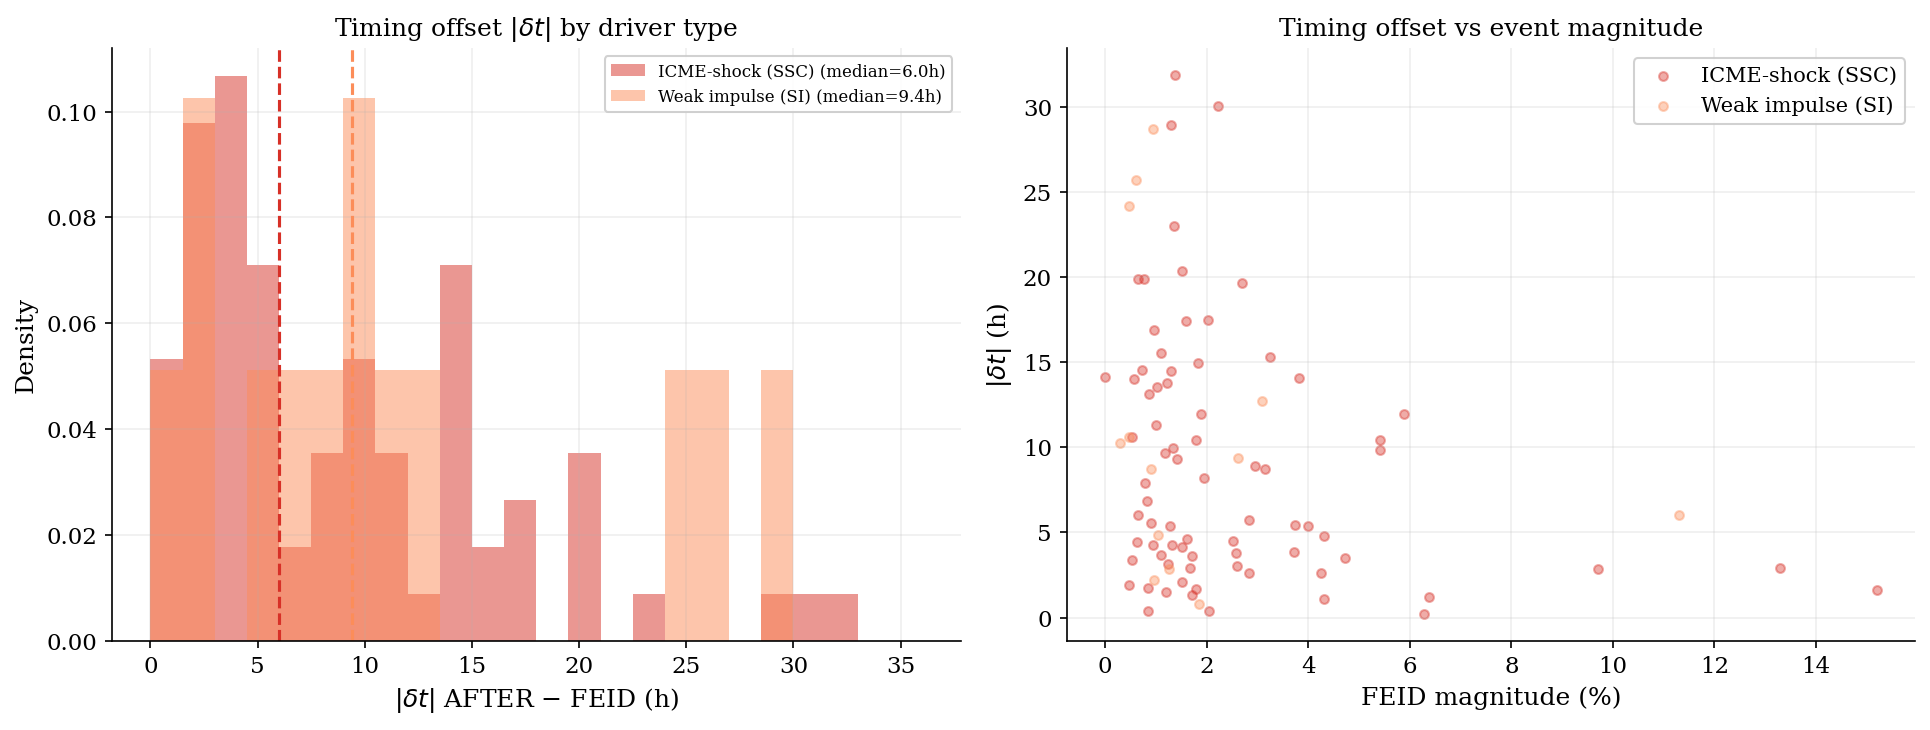

δt by driver (hours):
  SSC  : median=6.0h  mean=8.9h  q25=3.3h  q75=13.9h
  SI   : median=9.4h  mean=11.3h  q25=4.9h  q75=12.8h


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: δt distribution by driver
bins_dt = np.linspace(0, 36, 25)
for drv in ["SSC","SI","CIR"]:
    sub = matched_char[matched_char["driver"]==drv]["delta_t_h"].dropna()
    if len(sub) < 3:
        continue
    axes[0].hist(sub, bins=bins_dt, density=True,
                 color=DRIVER_COLORS[drv], alpha=0.5,
                 label=f"{DRIVER_LABELS[drv]} "
                       f"(median={sub.median():.1f}h)")
    axes[0].axvline(sub.median(), color=DRIVER_COLORS[drv],
                    ls="--", lw=1.5)

axes[0].set_xlabel(r"$|\delta t|$ AFTER − FEID (h)")
axes[0].set_ylabel("Density")
axes[0].set_title(r"Timing offset $|\delta t|$ by driver type")
axes[0].legend(fontsize=8, framealpha=0.9)
axes[0].grid(True, alpha=0.2)

# Right: δt vs FEID magnitude
for drv in ["SSC","SI","CIR"]:
    sub = matched_char[matched_char["driver"]==drv]
    if len(sub) < 3:
        continue
    axes[1].scatter(sub["feid_mag_36h"], sub["delta_t_h"],
                    color=DRIVER_COLORS[drv], alpha=0.4, s=18,
                    label=DRIVER_LABELS[drv])

axes[1].set_xlabel("FEID magnitude (%)")
axes[1].set_ylabel(r"$|\delta t|$ (h)")
axes[1].set_title(r"Timing offset vs event magnitude")
axes[1].legend(fontsize=10, framealpha=0.9)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
savefig("fig4_timing_offset.pdf")

# Summary table
print("δt by driver (hours):")
for drv in ["SSC","SI","CIR"]:
    sub = matched_char[matched_char["driver"]==drv]["delta_t_h"].dropna()
    if len(sub)==0: continue
    print(f"  {drv:5s}: median={sub.median():.1f}h  "
          f"mean={sub.mean():.1f}h  "
          f"q25={sub.quantile(0.25):.1f}h  q75={sub.quantile(0.75):.1f}h")


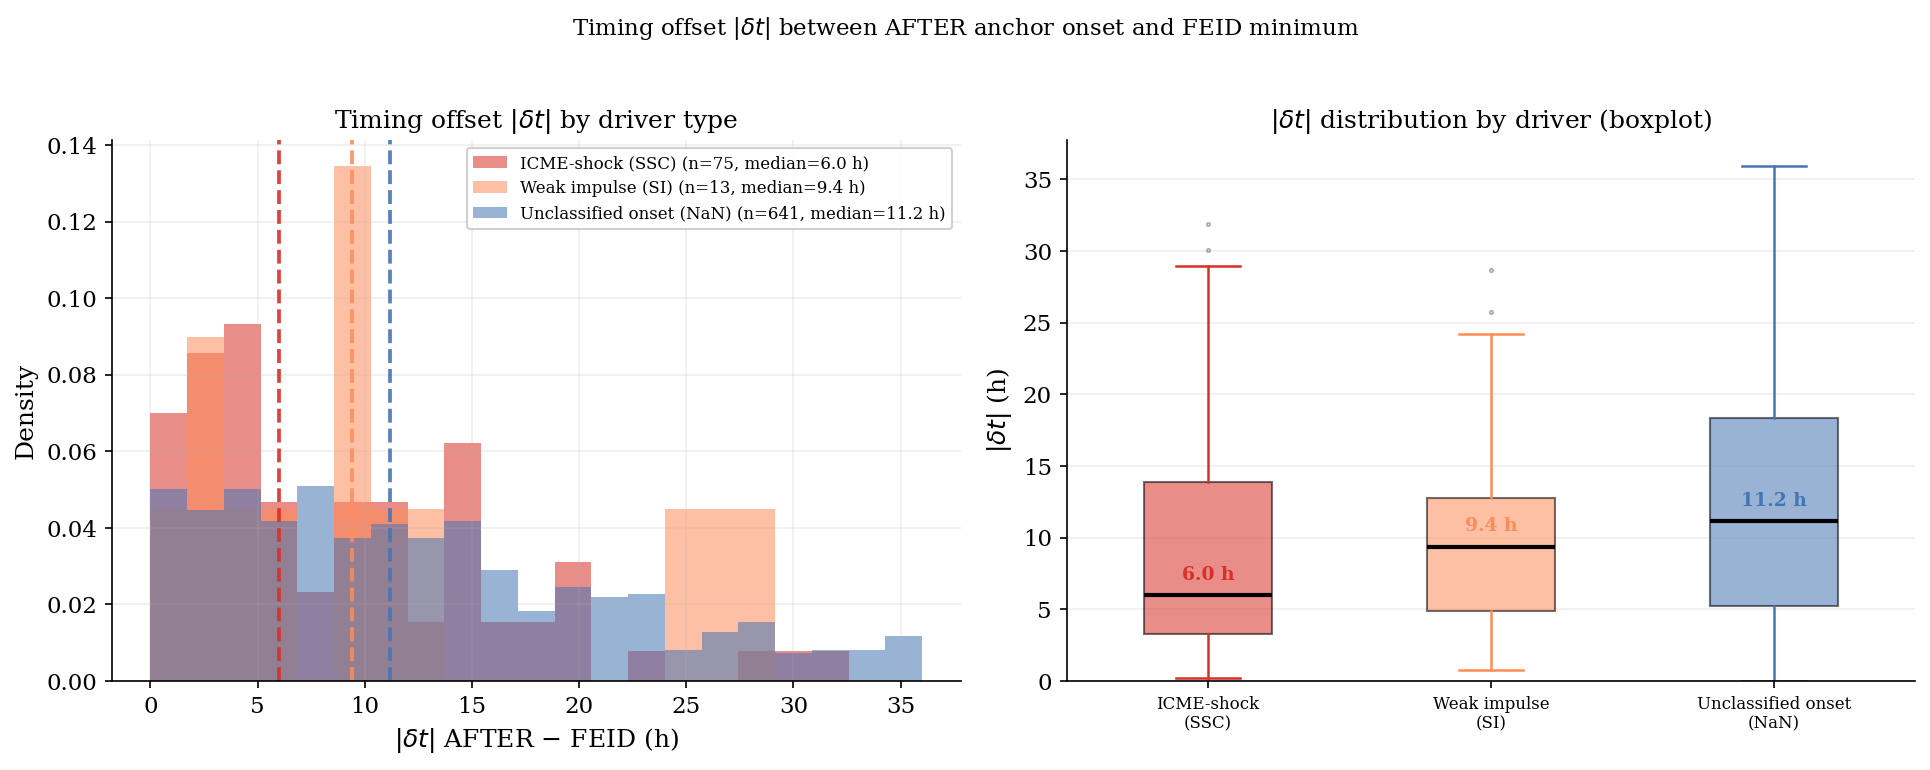

δt by driver (hours):
  SSC            : n=  75  median=6.0h  mean=8.9h  Q1=3.3h  Q3=13.9h
  SI             : n=  13  median=9.4h  mean=11.3h  Q1=4.9h  Q3=12.8h
  unclassified   : n= 641  median=11.2h  mean=12.6h  Q1=5.2h  Q3=18.4h


In [11]:
# ── Fig 4: Timing offset ─────────────────────────────────────────────────────
# Correcciones:
#   1. "CIR" → "unclassified" para coincidir con nomenclatura actual
#   2. Panel derecho: boxplot por driver en lugar de scatter denso
#      (más informativo con n=641 puntos unclassified)
#   3. Añadir línea de mediana anotada en panel izquierdo

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel izquierdo: distribución de δt por driver ────────────────────────────
bins_dt = np.linspace(0, 36, 22)
plot_drivers_dt = ["SSC", "SI", "unclassified"]

for drv in plot_drivers_dt:
    sub = matched_char[matched_char["driver"]==drv]["delta_t_h"].dropna()
    if len(sub) < 3:
        continue
    med = sub.median()
    axes[0].hist(sub, bins=bins_dt, density=True,
                 color=DRIVER_COLORS[drv], alpha=0.55,
                 label=f"{DRIVER_LABELS[drv]} (n={len(sub)}, "
                       f"median={med:.1f} h)")
    axes[0].axvline(med, color=DRIVER_COLORS[drv],
                    ls="--", lw=1.8, alpha=0.9)

axes[0].set_xlabel(r"$|\delta t|$ AFTER $-$ FEID (h)")
axes[0].set_ylabel("Density")
axes[0].set_title(r"Timing offset $|\delta t|$ by driver type")
axes[0].legend(fontsize=8, framealpha=0.9)
axes[0].grid(True, alpha=0.2)

# ── Panel derecho: boxplot δt vs driver (más limpio que scatter denso) ─────────
# Organizar datos para boxplot
box_data   = []
box_labels = []
box_colors = []

for drv in plot_drivers_dt:
    sub = matched_char[matched_char["driver"]==drv]["delta_t_h"].dropna()
    if len(sub) < 3:
        continue
    box_data.append(sub.values)
    box_labels.append(DRIVER_LABELS[drv].replace(" (", "\n("))
    box_colors.append(DRIVER_COLORS[drv])

bp = axes[1].boxplot(box_data,
                      patch_artist=True,
                      widths=0.45,
                      medianprops=dict(color="black", lw=2),
                      whiskerprops=dict(lw=1.2),
                      capprops=dict(lw=1.2),
                      flierprops=dict(marker=".", markersize=3,
                                      alpha=0.3, linestyle="none"))

for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)

for whisker, color in zip(bp["whiskers"],
                           [c for c in box_colors for _ in range(2)]):
    whisker.set_color(color)

for cap, color in zip(bp["caps"],
                       [c for c in box_colors for _ in range(2)]):
    cap.set_color(color)

# Anotar mediana sobre cada box
for i, (data, color) in enumerate(zip(box_data, box_colors), start=1):
    med = np.median(data)
    axes[1].text(i, med + 0.8, f"{med:.1f} h",
                  ha="center", va="bottom", fontsize=9,
                  color=color, fontweight="bold")

axes[1].set_xticks(range(1, len(box_labels)+1))
axes[1].set_xticklabels(box_labels, fontsize=8)
axes[1].set_ylabel(r"$|\delta t|$ (h)")
axes[1].set_title(r"$|\delta t|$ distribution by driver (boxplot)")
axes[1].set_ylim(bottom=0)
axes[1].grid(True, axis="y", alpha=0.2)

plt.suptitle(
    r"Timing offset $|\delta t|$ between AFTER anchor onset and FEID minimum",
    y=1.02, fontsize=11)
plt.tight_layout()
savefig("fig4_timing_offset.pdf")

# ── Tabla de resumen ──────────────────────────────────────────────────────────
print("δt by driver (hours):")
for drv in plot_drivers_dt:
    sub = matched_char[matched_char["driver"]==drv]["delta_t_h"].dropna()
    if len(sub) == 0:
        continue
    print(f"  {drv:15s}: n={len(sub):>4}  "
          f"median={sub.median():.1f}h  "
          f"mean={sub.mean():.1f}h  "
          f"Q1={sub.quantile(0.25):.1f}h  "
          f"Q3={sub.quantile(0.75):.1f}h")

## 5. Key numbers for the paper

In [12]:
print("=== Key numbers for characterization paper ===\n")

print(f"Total AFTER events: {len(cat_char)}")
print(f"Matched at ±36h:    {cat_char['feid_matched_36h'].sum()} "
      f"({cat_char['feid_matched_36h'].mean()*100:.1f}%)")
print(f"  SSC (ICME-shock): {(cat_char['driver']=='SSC').sum()}")
print(f"  SI (weak impulse):{(cat_char['driver']=='SI').sum()}")
print(f"  CIR/diffuse:      {(cat_char['driver']=='CIR').sum()}")
print(f"  Unmatched:        {(cat_char['driver']=='unmatched').sum()}")

print(f"\nKS test significance (SSC vs CIR):")
for col, label in [("n_sup_stations","nsup"),
                    ("A_complex_mean","A_complex"),
                    ("duration_h","duration"),
                    ("drop_max","drop_max")]:
    if col not in cat_char.columns: continue
    x = cat_char[cat_char["driver"]=="SSC"][col].dropna()
    y = cat_char[cat_char["driver"]=="unclassified"][col].dropna()
    if len(x)>5 and len(y)>5:
        ks, p = stats.ks_2samp(x,y)
        sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
        print(f"  {label:15s}: KS={ks:.3f}  p={p:.4f}  {sig}")

print(f"\nδt median by driver:")
for drv in ["SSC","SI","CIR"]:
    sub = matched_char[matched_char["driver"]==drv]["delta_t_h"].dropna()
    if len(sub)>0:
        print(f"  {drv}: {sub.median():.1f}h")

df_key = pd.DataFrame({
    "metric": [
        "n_total","n_matched_36h","n_SSC","n_SI","n_CIR","n_unmatched",
        "pct_matched","mean_nsup_SSC","mean_nsup_CIR",
        "median_dt_SSC","median_dt_CIR",
    ],
    "value": [
        len(cat_char),
        int(cat_char["feid_matched_36h"].sum()),
        int((cat_char["driver"]=="SSC").sum()),
        int((cat_char["driver"]=="SI").sum()),
        int((cat_char["driver"]=="unclassified").sum()),
        int((cat_char["driver"]=="unmatched").sum()),
        round(cat_char["feid_matched_36h"].mean()*100,1),
        round(cat_char[cat_char["driver"]=="SSC"]["n_sup_stations"].mean(),2),
        round(cat_char[cat_char["driver"]=="unclassified"]["n_sup_stations"].mean(),2),
        round(matched_char[matched_char["driver"]=="SSC"]["delta_t_h"].median(),1),
        round(matched_char[matched_char["driver"]=="unclassified"]["delta_t_h"].median(),1),
    ]
})
display(df_key)
df_key.to_csv(OUT / "table_key_numbers_characterization.csv", index=False)
print(f"\n✓ All outputs saved to: {OUT.resolve()}")


=== Key numbers for characterization paper ===

Total AFTER events: 908
Matched at ±36h:    729 (80.3%)
  SSC (ICME-shock): 75
  SI (weak impulse):13
  CIR/diffuse:      0
  Unmatched:        179

KS test significance (SSC vs CIR):
  nsup           : KS=0.484  p=0.0000  ***
  A_complex      : KS=0.079  p=0.7691  ns
  duration       : KS=0.232  p=0.0011  **
  drop_max       : KS=0.361  p=0.0000  ***

δt median by driver:
  SSC: 6.0h
  SI: 9.4h


,metric,value
0,n_total,908.00
1,n_matched_36h,729.00
2,n_SSC,75.00
3,n_SI,13.00
4,n_CIR,641.00
5,n_unmatched,179.00
6,pct_matched,80.30
7,mean_nsup_SSC,11.08
8,mean_nsup_CIR,6.17
9,median_dt_SSC,6.00



✓ All outputs saved to: /Users/neno/Documents/NMDB/SierraMethod/NEWVERSION/Results_v2_4/Characterization


In [13]:
#For precision:
for drv in ["SSC","SI","unclassified","unmatched"]:
    sub = cat_char[cat_char["driver"]==drv]
    for col in ["n_sup_stations","duration_h","drop_max","A_complex_mean"]:
        if col in sub.columns:
            q = sub[col].quantile
            print(f"{drv} {col}: "
                  f"median={q(0.5):.1f} "
                  f"IQR=({q(0.25):.1f}--{q(0.75):.1f})")

SSC n_sup_stations: median=12.0 IQR=(8.5--14.0)
SSC duration_h: median=49.1 IQR=(33.9--69.5)
SSC drop_max: median=6.5 IQR=(5.2--8.7)
SSC A_complex_mean: median=6.3 IQR=(5.7--7.3)
SI n_sup_stations: median=13.0 IQR=(11.0--15.0)
SI duration_h: median=65.6 IQR=(44.4--81.3)
SI drop_max: median=7.1 IQR=(5.3--9.9)
SI A_complex_mean: median=6.3 IQR=(6.1--6.8)
unclassified n_sup_stations: median=5.0 IQR=(3.0--9.0)
unclassified duration_h: median=35.9 IQR=(21.7--62.0)
unclassified drop_max: median=4.9 IQR=(3.8--6.3)
unclassified A_complex_mean: median=6.4 IQR=(5.4--7.5)
unmatched n_sup_stations: median=5.0 IQR=(2.0--9.0)
unmatched duration_h: median=34.6 IQR=(19.5--54.5)
unmatched drop_max: median=4.8 IQR=(3.8--6.6)
unmatched A_complex_mean: median=6.5 IQR=(5.3--7.8)


In [14]:
print(f"unclassified: {matched_char[matched_char['driver']=='unclassified']['delta_t_h'].median():.1f}h")

unclassified: 11.2h


In [15]:
matched_char[matched_char["driver"]=="unclassified"]["delta_t_h"].median()

np.float64(11.166666666666666)

In [16]:
from scipy import stats

matched = cat_char[cat_char["feid_matched_36h"]==True].copy()

for col, label in [("feid_vmax_36h", "V_max"),
                   ("feid_bmax_36h", "B_max")]:
    if col in matched.columns:
        x = matched[col].dropna()
        y = matched.loc[x.index, "feid_mag_36h"].dropna()
        idx = x.index.intersection(y.index)
        r, p = stats.pearsonr(x.loc[idx], y.loc[idx])
        print(f"  FD_mag vs {label}: r={r:.3f}  p={p:.4f}")

  FD_mag vs V_max: r=0.353  p=0.0000
  FD_mag vs B_max: r=0.755  p=0.0000


In [17]:
## Kruskal-Wallis for δt:

In [18]:
from scipy import stats

# Kruskal-Wallis para δt por driver
groups = {}
for drv in ["SSC", "SI", "unclassified"]:
    g = matched_char[matched_char["driver"]==drv]["delta_t_h"].dropna()
    groups[drv] = g
    print(f"{drv:15s}: n={len(g):>4}  "
          f"median={g.median():.1f}h  "
          f"IQR=({g.quantile(0.25):.1f}–{g.quantile(0.75):.1f}h)")

H, p_kw = stats.kruskal(*groups.values())
print(f"\nKruskal-Wallis: H={H:.3f}  p={p_kw:.4f}")

# Pairwise Mann-Whitney con corrección de Bonferroni
pairs = [("SSC","SI"), ("SSC","unclassified"), ("SI","unclassified")]
print("\nPairwise Mann-Whitney (Bonferroni α=0.0167):")
for a, b in pairs:
    U, p = stats.mannwhitneyu(groups[a], groups[b], alternative="two-sided")
    n1, n2 = len(groups[a]), len(groups[b])
    r = 1 - 2*U/(n1*n2)   # rank-biserial effect size
    sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.0167 else "ns"
    print(f"  {a:15s} vs {b:15s}: U={U:.0f}  p={p:.4f}  r={r:.3f}  {sig}")

SSC            : n=  75  median=6.0h  IQR=(3.3–13.9h)
SI             : n=  13  median=9.4h  IQR=(4.9–12.8h)
unclassified   : n= 641  median=11.2h  IQR=(5.2–18.4h)

Kruskal-Wallis: H=11.414  p=0.0033

Pairwise Mann-Whitney (Bonferroni α=0.0167):
  SSC             vs SI             : U=424  p=0.4623  r=0.129  ns
  SSC             vs unclassified   : U=18358  p=0.0008  r=0.236  ***
  SI              vs unclassified   : U=3764  p=0.5511  r=0.097  ns
